# EDA

## Description

basically, if we train with imbalanced data, we will two major issues :
- **overfitting**: since we have 478 fraud cases of over 250 000 total transacion
- **Wrong Correlations**: since the 'V1 .. V28' features are already transformed with PCA for generally Privacy and protection of user credentials

in this notebook, our goals are Analysis and Processing the dataset through:
- removing duplications
- applying undersampling (choosing number of normal transactions equal to fraud)
- visualizing the distributions
- scaling the remaining features

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

from sklearn.manifold import TSNE
from sklearn.decomposition import PCA, TruncatedSVD
import matplotlib.patches as mpatches

from sklearn.preprocessing import StandardScaler, RobustScaler

In [3]:
df = pd.read_csv("../data/raw/creditcard.csv")

In [4]:
dup = df.duplicated().sum()
print(dup)
if dup > 0:
    df = df.drop_duplicates()

1081


In [5]:
df.shape

(283726, 31)

In [6]:
print('No Frauds ==', df['Class'].value_counts()[0]/len(df) * 100, '% of the dataset')
print('Frauds =====', df['Class'].value_counts()[1]/len(df) * 100, '% of the dataset')

No Frauds == 99.83328986416473 % of the dataset
Frauds ===== 0.1667101358352777 % of the dataset


In [7]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## UnderSampling

And now, we will select 437 cases of normal transactions, it will be randomly selected
- its purpose is only for visualization


In [8]:
# shuffling the data: shuffling after splitting is normal, since the train/test/labels variable are just lists that contains
# random shuffling
df = df.sample(frac=1)

fraud_num = df['Class'].value_counts()[1]

# amount of fraud classes .
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:fraud_num]

normal_distributed_df = pd.concat([fraud_df, non_fraud_df])

# Shuffle dataframe rows
US = normal_distributed_df.sample(frac=1, random_state=42)

print(US['Class'].value_counts()) # counting fraud and normal transactions separatly


Class
1    473
0    473
Name: count, dtype: int64


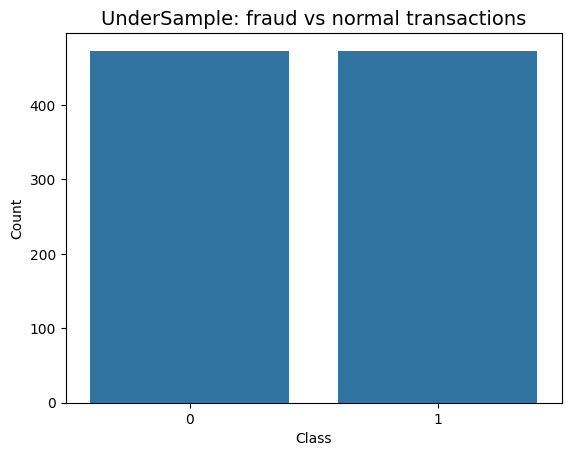

In [9]:
sns.countplot(x='Class', data=US)  # Note: Class 0 is normal transaction, 1 is fraud

plt.title("UnderSample: fraud vs normal transactions", fontsize=14)
plt.xlabel("Class")
plt.ylabel("Count")

plt.show()

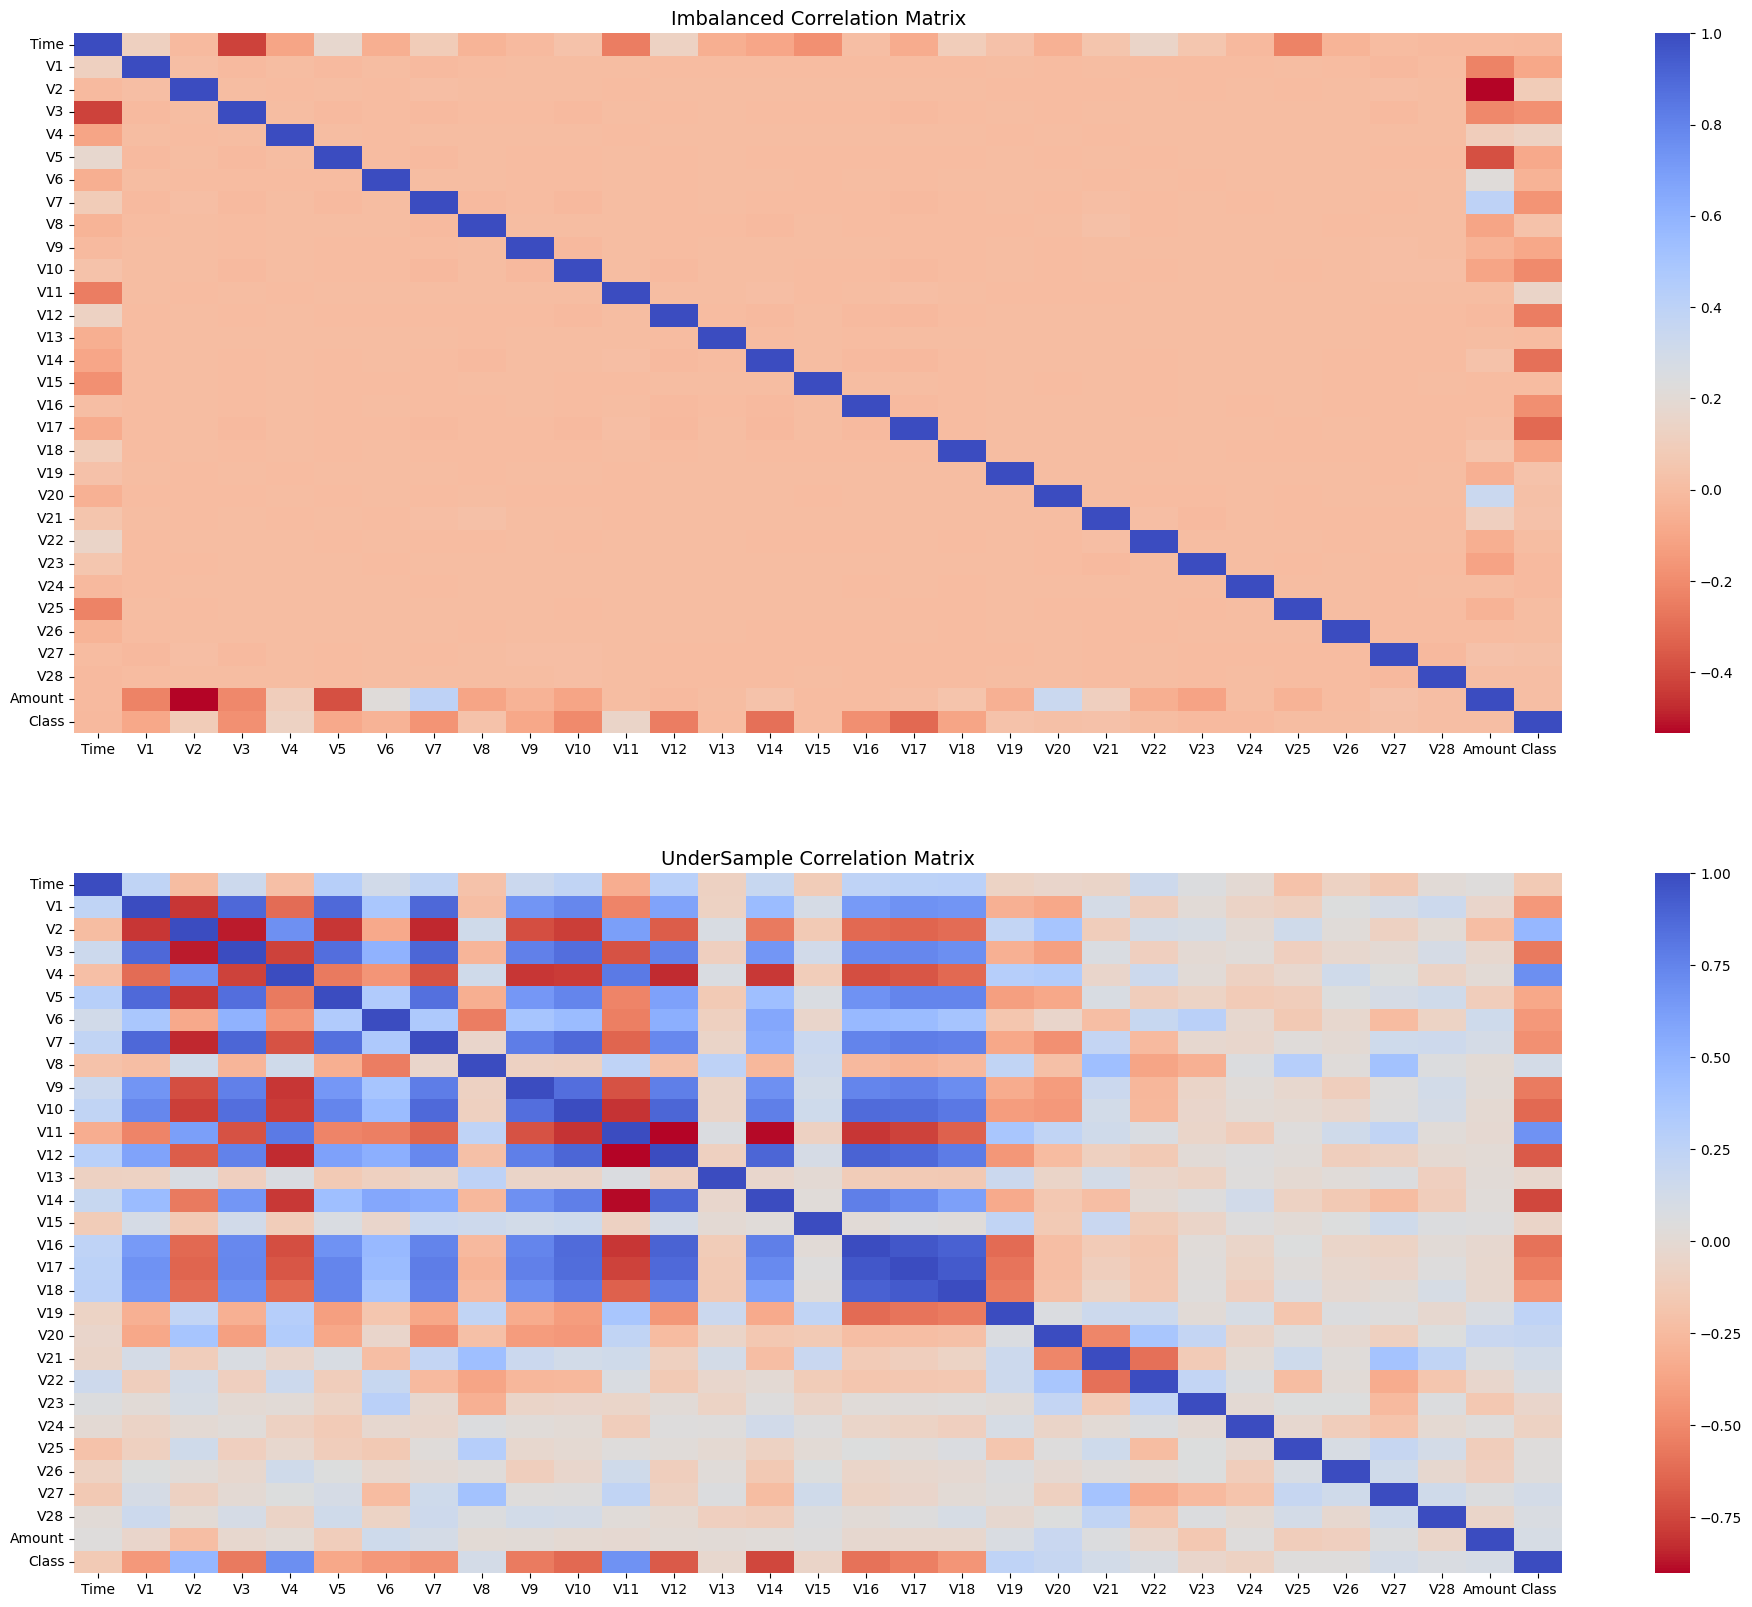

In [10]:
f, (ax1, ax2) = plt.subplots(2, 1, figsize=(24,20))

# Entire DataFrame
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax1)
ax1.set_title("Imbalanced Correlation Matrix", fontsize=14)


sub_sample_corr = US.corr()
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot_kws={'size':20}, ax=ax2)
ax2.set_title('UnderSample Correlation Matrix', fontsize=14)
plt.show()

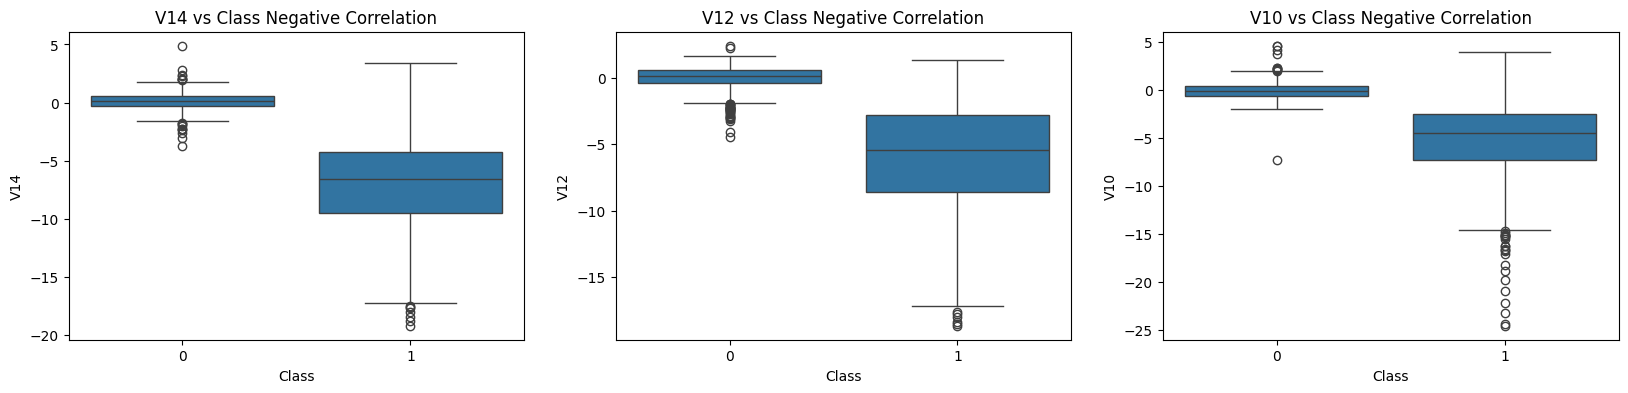

In [57]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

# Negative Correlations with our Class (The lower our feature value the more likely it will be a fraud transaction)

sns.boxplot(x="Class", y="V14", data=US, ax=axes[0])
axes[0].set_title('V14 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V12", data=US, ax=axes[1])
axes[1].set_title('V12 vs Class Negative Correlation')

sns.boxplot(x="Class", y="V10", data=US, ax=axes[2])
axes[2].set_title('V10 vs Class Negative Correlation')

plt.show()

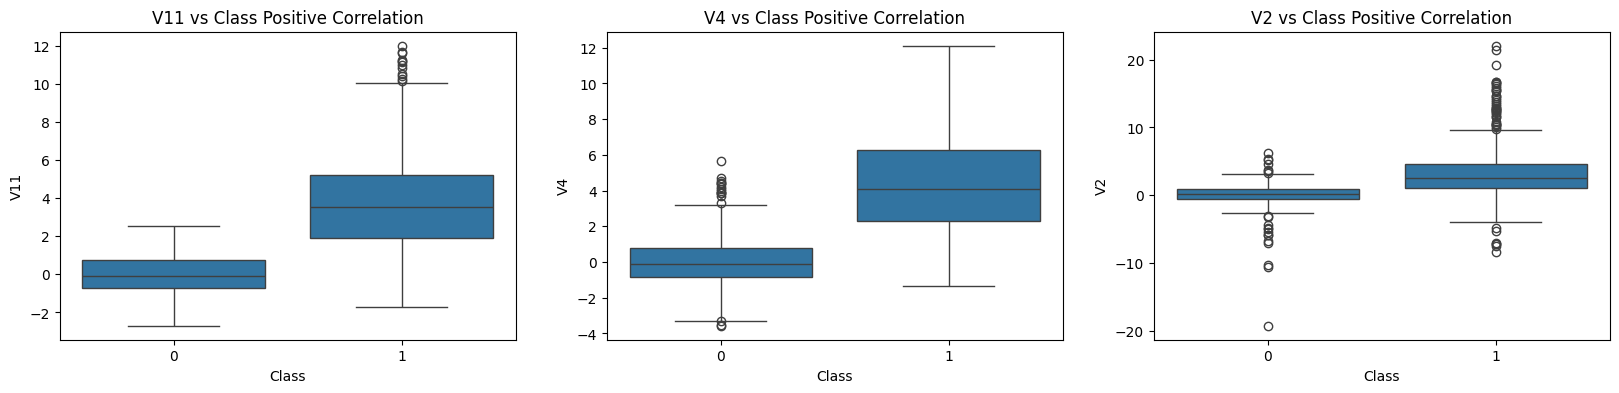

In [58]:
f, axes = plt.subplots(ncols=3, figsize=(20,4))

# Positive correlations (The higher the feature the probability increases that it will be a fraud transaction)
sns.boxplot(x="Class", y="V11", data=US, ax=axes[0])
axes[0].set_title('V11 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V4", data=US, ax=axes[1])
axes[1].set_title('V4 vs Class Positive Correlation')

sns.boxplot(x="Class", y="V2", data=US, ax=axes[2])
axes[2].set_title('V2 vs Class Positive Correlation')

plt.show()

# Scaling Features

In This Section, We will scale the other Features (Amount, Time), since the other Features are already transformed with PCA

In [11]:
# Since most of our data has already been scaled we should scale the columns that are left to scale (Amount and Time)

# RobustScaler is less prone to outliers.

std_scaler = StandardScaler()
rob_scaler = RobustScaler()

df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = std_scaler.fit_transform(df['Time'].values.reshape(-1,1))

df.drop(['Time','Amount'], axis=1, inplace=True)

In [12]:
df

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
219025,0.114965,0.766762,-0.494132,0.116772,0.868169,-0.477982,0.438496,0.063073,-0.186207,-0.159325,...,-0.706865,0.131405,0.600742,-0.604264,0.262938,0.099145,0.010810,1,-0.243499,0.984688
128246,1.157505,0.194266,0.095280,1.035788,-0.221568,-0.331892,-0.165681,0.048874,0.607821,-0.814615,...,-0.175754,-0.063457,0.021864,0.469866,0.441097,0.016851,0.039409,0,-0.134752,-0.340412
155259,1.936689,-0.016661,-1.646931,0.491988,0.310135,-0.663695,-0.037829,-0.194088,2.107250,-1.049942,...,-0.638143,0.093808,-0.671878,-0.074780,-0.120907,-0.046553,-0.036001,0,0.389376,0.213221
137702,-0.804381,-0.039338,0.544332,-2.597223,-1.103569,-0.204359,-0.872924,0.559574,-2.095116,1.350190,...,0.011286,0.035669,-0.377045,-0.329598,-0.407443,-0.229941,0.036372,0,-0.166875,-0.263749
60681,1.051131,0.078365,1.371753,2.662810,-0.347892,1.390227,-0.742831,0.466555,0.100451,0.486556,...,0.652637,-0.161363,-0.230979,0.584717,0.242936,0.066086,0.011721,0,-0.305938,-0.955437
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179797,-1.768804,0.784828,0.308045,2.473830,1.548611,-0.176318,0.799638,0.343529,-2.058190,0.417257,...,0.591055,-0.500519,0.619267,0.175572,-0.013204,-0.047935,-0.127043,0,0.746211,0.619889
54160,1.268712,-0.770499,0.585889,-0.814853,-1.056622,-0.049472,-0.828265,0.047259,-0.872588,0.770514,...,-0.900940,0.054887,-0.329283,-0.029904,0.874340,-0.040868,0.014407,0,0.512307,-1.021443
45496,1.023445,0.011604,0.873610,1.661036,-0.789501,-0.707008,0.064672,-0.164857,0.365684,-0.179857,...,0.149322,-0.104871,0.973998,0.636557,-0.341959,0.033814,0.042210,0,0.722987,-1.104381
234515,2.137544,-0.046835,-1.490942,0.167773,0.398305,-0.610113,0.187714,-0.290312,0.553954,0.063812,...,-0.858167,0.207849,-0.993062,-0.146163,0.259187,-0.069380,-0.069800,0,-0.293561,1.120342


In [68]:
df.to_csv("../data/preprocessed/creditcard_Processed.csv", index=False)

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,      # preserves class proportions
    random_state=42
)

print("Original:")
print(y.value_counts(normalize=True) * 100)

print("\nTrain:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest:")
print(y_test.value_counts(normalize=True) * 100)